In [1]:
import torch

print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

!nvidia-smi

GPU available: True
Device: cuda
Fri May 22 09:35:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------

In [4]:
# 1. Download using the exact API link
!wget -O train_val.tar.gz "https://zenodo.org/api/records/14963880/files/RRDataset_original_train_val.tar.gz/content"

# 2. Re-create directory and extract
!mkdir -p /kaggle/working/data
!tar -xzf train_val.tar.gz -C /kaggle/working/data

# 3. View the top-level folders
!ls /kaggle/working/data

--2026-05-22 09:36:28--  https://zenodo.org/api/records/14963880/files/RRDataset_original_train_val.tar.gz/content
Resolving zenodo.org (zenodo.org)... failed: Temporary failure in name resolution.
wget: unable to resolve host address ‘zenodo.org’

gzip: stdin: unexpected end of file
tar: Child returned status 1
tar: Error is not recoverable: exiting now


In [3]:
from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm import tqdm

DATASET_ROOT = Path("/kaggle/working/data")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
rows = []

all_paths = list(DATASET_ROOT.rglob("*"))

print("Scanning images and extracting metadata...")
for img_path in tqdm(all_paths):
    if img_path.suffix.lower() not in IMAGE_EXTS:
        continue

    # Get lowercase path parts
    parts = [p.lower() for p in img_path.relative_to(DATASET_ROOT).parts]

    # FIX: Use substring matching (checking if keyword is INSIDE any part)
    if any("real" in p for p in parts):
        binary_label = "real"
    elif any("ai" in p or "fake" in p for p in parts) :
        binary_label = "fake"
    else:
        binary_label = "unknown"

    # FIX: Use substring matching for transformations
    if any("original" in p for p in parts):
        transform_label = "original"
    elif any(k in p for p in parts for k in ["transfer", "transmit", "internet", "social"]):
        transform_label = "transmitted"
    elif any(k in p for p in parts for k in ["redigital", "screen"]):
        transform_label = "redigitalized"
    else:
        transform_label = "unknown"

    try:
        with Image.open(img_path) as img:
            width, height = img.size
            is_corrupted = False
    except Exception:
        width, height = None, None
        is_corrupted = True

    rows.append({
        "filepath": str(img_path),
        "binary_label": binary_label,
        "transform_label": transform_label,
        "width": width,
        "height": height,
        "is_corrupted": is_corrupted
    })

df = pd.DataFrame(rows)
df.to_csv("/kaggle/working/metadata.csv", index=False)

print(f"\nScan Complete! Total images indexed: {len(df)}")
print("\nJoint Multi-Task Balance Matrix:")
print(pd.crosstab(df["transform_label"], df["binary_label"]))

Scanning images and extracting metadata...


0it [00:00, ?it/s]


Scan Complete! Total images indexed: 0

Joint Multi-Task Balance Matrix:


KeyError: 'transform_label'

In [5]:
import torch

CONFIG = {
    "seed": 42,
    "img_size": 224,
    "batch_size": 32,
    "epochs": 10,
    "lr": 1e-4,
    "subset_per_class": 1000,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load inventory and drop corrupted OR unknown rows
df = pd.read_csv("/kaggle/working/metadata.csv")

# CRITICAL FIX: Filter out "unknown" labels
df = df[
    (df["is_corrupted"] == False) & 
    (df["binary_label"] != "unknown") & 
    (df["transform_label"] != "unknown")
]

# 2. Sample a balanced subset based on CONFIG
balanced_df = (
    df.groupby(["binary_label", "transform_label"])
    .apply(lambda x: x.sample(min(len(x), CONFIG["subset_per_class"]), random_state=CONFIG["seed"]))
    .reset_index(drop=True)
)

# 3. Create a clean 80/20 Train/Validation Split
train_df, val_df = train_test_split(
    balanced_df, 
    test_size=0.2, 
    stratify=balanced_df[["binary_label", "transform_label"]], 
    random_state=CONFIG["seed"]
)

print(f"Cleaned Train subset size: {len(train_df)}")
print(f"Cleaned Validation subset size: {len(val_df)}")

Cleaned Train subset size: 1600
Cleaned Validation subset size: 400


/tmp/ipykernel_56/2883457051.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), CONFIG["subset_per_class"]), random_state=CONFIG["seed"]))


In [7]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class MultiTaskDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        # Map text labels to integers
        self.binary_map = {"real": 0, "fake": 1}
        self.transform_map = {"original": 0, "transmitted": 1, "redigitalized": 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
            
        # Get labels and convert to torch tensors
        label_bin = torch.tensor(self.binary_map[row["binary_label"]], dtype=torch.long)
        label_trans = torch.tensor(self.transform_map[row["transform_label"]], dtype=torch.long)
        
        return img, label_bin, label_trans

In [8]:
from torch.utils.data import DataLoader

# Standard ImageNet preprocessing
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(), # Basic augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate Datasets
train_dataset = MultiTaskDataset(train_df, transform=train_transform)
val_dataset = MultiTaskDataset(val_df, transform=val_transform)

# Instantiate DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

In [9]:
import torch.nn as nn
from torchvision import models

class MultiTaskResNet(nn.Module):
    def __init__(self):
        super(MultiTaskResNet, self).__init__()
        # Load a lightweight, powerful pre-trained backbone
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Find the number of input features to the original final layer
        num_features = self.backbone.fc.in_features
        
        # Remove the original classification layer
        self.backbone.fc = nn.Identity()
        
        # Create Task Head 1: Binary (Real vs Fake -> 2 classes)
        self.binary_head = nn.Linear(num_features, 2)
        
        # Create Task Head 2: Multi-class (Original vs Transmitted vs Redigitalized -> 3 classes)
        self.transform_head = nn.Linear(num_features, 3)

    def forward(self, x):
        # Extract shared features
        features = self.backbone(x)
        
        # Pass features through both independent heads
        out_binary = self.binary_head(features)
        out_transform = self.transform_head(features)
        
        return out_binary, out_transform

In [10]:
model = MultiTaskResNet()
model = model.to(CONFIG["device"])
print("Model initialized on:", CONFIG["device"])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Model initialized on: cuda


In [11]:
import torch.optim as optim

# 1. Loss Functions and Optimizer
criterion_binary = nn.CrossEntropyLoss()
criterion_transform = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"])

# Loss weights (Ablation study targets)
w1, w2 = 0.5, 0.5

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_bin, correct_trans = 0, 0
    total = 0
    
    for images, labels_bin, labels_trans in dataloader:
        images = images.to(device)
        labels_bin = labels_bin.to(device)
        labels_trans = labels_trans.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        out_bin, out_trans = model(images)
        
        # Compute individual losses
        loss_bin = criterion_binary(out_bin, labels_bin)
        loss_trans = criterion_transform(out_trans, labels_trans)
        
        # Joint Loss Function
        total_loss = (w1 * loss_bin) + (w2 * loss_trans)
        
        # Backward pass and optimization
        total_loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += total_loss.item() * images.size(0)
        _, pred_bin = torch.max(out_bin, 1)
        _, pred_trans = torch.max(out_trans, 1)
        
        correct_bin += (pred_bin == labels_bin).sum().item()
        correct_trans += (pred_trans == labels_trans).sum().item()
        total += images.size(0)
        
    epoch_loss = running_loss / total
    acc_bin = correct_bin / total
    acc_trans = correct_trans / total
    
    return epoch_loss, acc_bin, acc_trans

In [12]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct_bin, correct_trans, total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels_bin, labels_trans in dataloader:
            images = images.to(device)
            labels_bin = labels_bin.to(device)
            labels_trans = labels_trans.to(device)
            
            out_bin, out_trans = model(images)
            
            _, pred_bin = torch.max(out_bin, 1)
            _, pred_trans = torch.max(out_trans, 1)
            
            correct_bin += (pred_bin == labels_bin).sum().item()
            correct_trans += (pred_trans == labels_trans).sum().item()
            total += images.size(0)
            
    return correct_bin / total, correct_trans / total

# --- Main Training Loop ---
print("Starting Training...")
for epoch in range(CONFIG["epochs"]):
    # Train
    train_loss, train_acc_bin, train_acc_trans = train_epoch(
        model, train_loader, optimizer, CONFIG["device"]
    )
    
    # Validate
    val_acc_bin, val_acc_trans = evaluate_model(model, val_loader, CONFIG["device"])
    
    # Print progress
    print(f"\nEpoch [{epoch+1}/{CONFIG['epochs']}] Loss: {train_loss:.4f}")
    print(f"  [Train] Real/Fake Acc: {train_acc_bin*100:.2f}% | Transform Acc: {train_acc_trans*100:.2f}%")
    print(f"  [Val]   Real/Fake Acc: {val_acc_bin*100:.2f}% | Transform Acc: {val_acc_trans*100:.2f}%")

print("\nTraining complete!")

Starting Training...

Epoch [1/10] Loss: 0.3683
  [Train] Real/Fake Acc: 79.88% | Transform Acc: 93.06%
  [Val]   Real/Fake Acc: 87.75% | Transform Acc: 100.00%

Epoch [2/10] Loss: 0.0883
  [Train] Real/Fake Acc: 94.75% | Transform Acc: 100.00%
  [Val]   Real/Fake Acc: 88.25% | Transform Acc: 100.00%

Epoch [3/10] Loss: 0.0384
  [Train] Real/Fake Acc: 98.38% | Transform Acc: 100.00%
  [Val]   Real/Fake Acc: 86.75% | Transform Acc: 100.00%

Epoch [4/10] Loss: 0.0247
  [Train] Real/Fake Acc: 98.94% | Transform Acc: 100.00%
  [Val]   Real/Fake Acc: 88.00% | Transform Acc: 100.00%

Epoch [5/10] Loss: 0.0116
  [Train] Real/Fake Acc: 99.88% | Transform Acc: 100.00%
  [Val]   Real/Fake Acc: 90.00% | Transform Acc: 100.00%

Epoch [6/10] Loss: 0.0109
  [Train] Real/Fake Acc: 99.69% | Transform Acc: 100.00%
  [Val]   Real/Fake Acc: 89.50% | Transform Acc: 100.00%

Epoch [7/10] Loss: 0.0091
  [Train] Real/Fake Acc: 99.81% | Transform Acc: 100.00%
  [Val]   Real/Fake Acc: 90.00% | Transform Acc: 1

--- Real/Fake Classification Report ---
              precision    recall  f1-score   support

        Real       0.90      0.83      0.86       200
        Fake       0.84      0.91      0.87       200

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



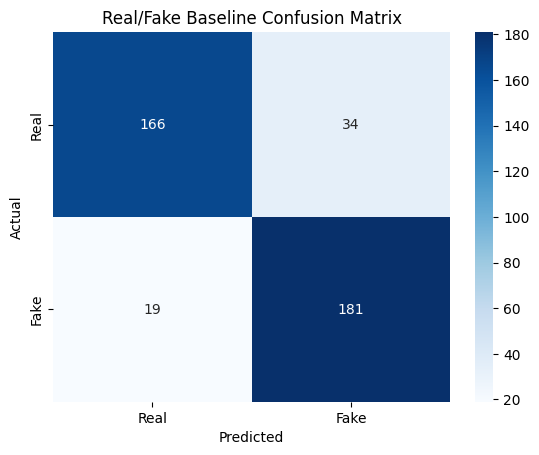

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test_and_report(model, dataloader, device):
    model.eval()
    all_preds_bin = []
    all_labels_bin = []
    
    with torch.no_grad():
        for images, labels_bin, _ in dataloader:
            images = images.to(device)
            out_bin, _ = model(images)
            _, preds = torch.max(out_bin, 1)
            
            all_preds_bin.extend(preds.cpu().numpy())
            all_labels_bin.extend(labels_bin.numpy())
            
    # Print metrics
    print("--- Real/Fake Classification Report ---")
    print(classification_report(all_labels_bin, all_preds_bin, target_names=["Real", "Fake"]))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels_bin, all_preds_bin)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Real/Fake Baseline Confusion Matrix')
    plt.show()

# Run it on your validation loader
test_and_report(model, val_loader, CONFIG["device"])

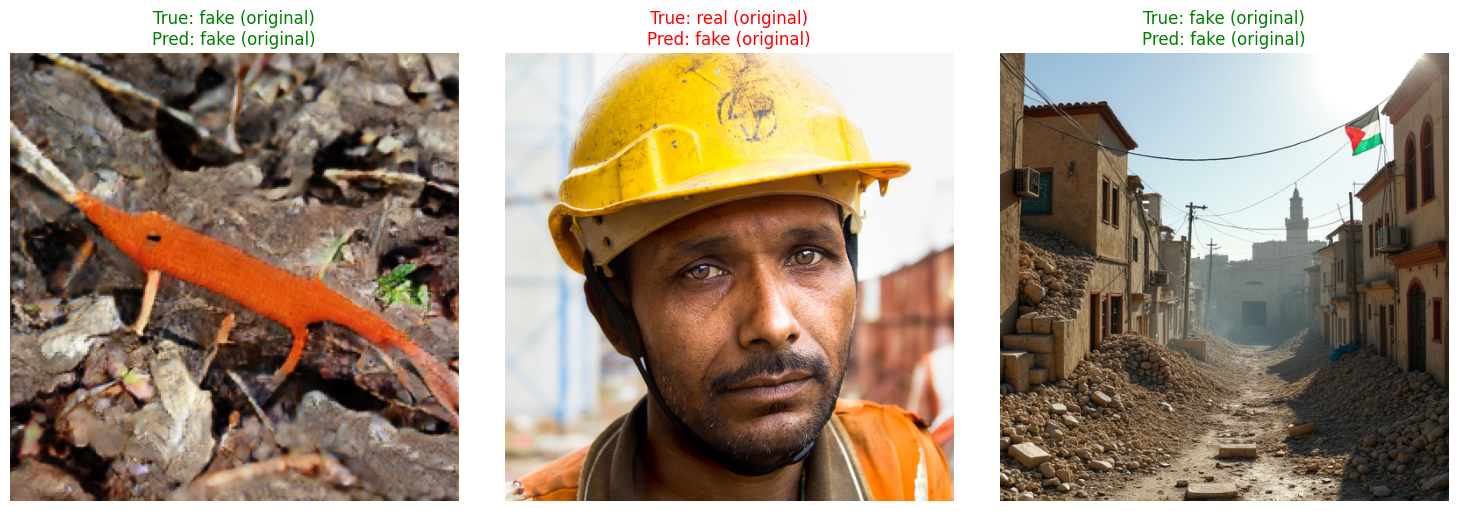

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

def run_visual_inference(model, df, num_samples=3):
    model.eval()
    
    # Reverse mappings to convert integers back to text strings
    inv_binary_map = {0: "real", 1: "fake"}
    inv_transform_map = {0: "original", 1: "transmitted", 2: "redigitalized"}
    
    # Pick random sample rows from your validation dataframe
    samples = df.sample(num_samples, random_state=42)
    
    plt.figure(figsize=(15, 5))
    
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row["filepath"]
        true_bin = row["binary_label"]
        true_trans = row["transform_label"]
        
        # 1. Load the raw image for plotting
        raw_img = Image.open(img_path).convert("RGB")
        
        # 2. Preprocess the image for the model (add batch dimension with unsqueeze)
        input_tensor = val_transform(raw_img).unsqueeze(0).to(CONFIG["device"])
        
        # 3. Model Prediction
        with torch.no_grad():
            out_bin, out_trans = model(input_tensor)
            _, pred_bin = torch.max(out_bin, 1)
            _, pred_trans = torch.max(out_trans, 1)
            
        p_bin = inv_binary_map[pred_bin.item()]
        p_trans = inv_transform_map[pred_trans.item()]
        
        # 4. Visualization Setup
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(raw_img)
        
        # Green title if real/fake prediction matches truth, red if it fails
        title_color = "green" if p_bin == true_bin else "red"
        
        plt.title(
            f"True: {true_bin} ({true_trans})\n"
            f"Pred: {p_bin} ({p_trans})", 
            color=title_color, 
            fontsize=12
        )
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Execute inference on 3 images from your validation set
run_visual_inference(model, val_df, num_samples=3)

In [15]:
import tarfile
import urllib.request
import os
import shutil

# Clear the old unbalanced test folder
shutil.rmtree("/kaggle/working/data/test_subset", ignore_errors=True)

url = "https://zenodo.org/api/records/14963880/files/RRDataset_test.tar.gz/content"
output_dir = "/kaggle/working/data/test_subset"

# Define targets and counters
counts = {
    "redigital_real": 0,
    "transmitted_real": 0,
    "transmitted_ai": 0
}
LIMIT = 1000 

print("Streaming and targeted extracting... This will skip unwanted files.")

with urllib.request.urlopen(url) as response:
    with tarfile.open(fileobj=response, mode="r|gz") as tar:
        for member in tar:
            if not (member.isfile() and member.name.lower().endswith(('.png', '.jpg', '.jpeg'))):
                continue
                
            parts = member.name.lower().split('/')
            
            # Identify the specific missing categories
            is_real = "real" in parts
            is_ai = "ai" in parts or "fake" in parts
            is_redigital = "redigital" in parts
            is_transmitted = any(k in parts for k in ["transfer", "transmitted", "internet"])
            
            key = None
            if is_redigital and is_real:
                key = "redigital_real"
            elif is_transmitted and is_real:
                key = "transmitted_real"
            elif is_transmitted and is_ai:
                key = "transmitted_ai"
                
            # If it's a category we need and we haven't hit the limit, extract it
            if key and counts[key] < LIMIT:
                tar.extract(member, path=output_dir)
                counts[key] += 1
                
                if sum(counts.values()) % 500 == 0:
                    print(f"Progress -> Redigital_Real: {counts['redigital_real']}, Transmitted_Real: {counts['transmitted_real']}, Transmitted_AI: {counts['transmitted_ai']}")
            
            # Stop early if all targets are met
            if all(c >= LIMIT for c in counts.values()):
                print("All missing categories successfully balanced!")
                break

print("\nExtraction finished. Final counts:", counts)

Streaming and targeted extracting... This will skip unwanted files.


/tmp/ipykernel_56/3635858268.py:46: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_dir)


Progress -> Redigital_Real: 500, Transmitted_Real: 0, Transmitted_AI: 0
Progress -> Redigital_Real: 1000, Transmitted_Real: 0, Transmitted_AI: 0
Progress -> Redigital_Real: 1000, Transmitted_Real: 0, Transmitted_AI: 500
Progress -> Redigital_Real: 1000, Transmitted_Real: 0, Transmitted_AI: 1000
Progress -> Redigital_Real: 1000, Transmitted_Real: 500, Transmitted_AI: 1000
Progress -> Redigital_Real: 1000, Transmitted_Real: 1000, Transmitted_AI: 1000
All missing categories successfully balanced!

Extraction finished. Final counts: {'redigital_real': 1000, 'transmitted_real': 1000, 'transmitted_ai': 1000}


In [16]:
from pathlib import Path
import os

# Check the subfolders inside the new test_subset directory
test_subset_path = Path("/kaggle/working/data/test_subset")

print("Folders extracted inside test_subset:")
for root, dirs, files in os.walk(test_subset_path):
    # Only print directories that actually contain files to keep it clean
    if files:
        relative_path = Path(root).relative_to(test_subset_path)
        print(f"  - {relative_path} ({len(files)} images)")

Folders extracted inside test_subset:
  - RRDataset_final/redigital/real (1000 images)
  - RRDataset_final/transfer/real (1000 images)
  - RRDataset_final/transfer/ai (1000 images)


In [17]:
import tarfile
import urllib.request
import os
from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm import tqdm

# 1. Grab the final missing category: redigital_ai
url = "https://zenodo.org/api/records/14963880/files/RRDataset_test.tar.gz/content"
output_dir = "/kaggle/working/data/test_subset"
count = 0

print("Pulling the final 1000 redigital_ai images...")
with urllib.request.urlopen(url) as response:
    with tarfile.open(fileobj=response, mode="r|gz") as tar:
        for member in tar:
            if member.isfile() and member.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                parts = member.name.lower().split('/')
                if "redigital" in parts and ("ai" in parts or "fake" in parts):
                    if count < 1000:
                        tar.extract(member, path=output_dir)
                        count += 1
                    else:
                        break

# 2. Re-run the Metadata Scanner over EVERYTHING
DATASET_ROOT = Path("/kaggle/working/data")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
rows = []

print("\nScanning entire dataset directory...")
for img_path in tqdm(list(DATASET_ROOT.rglob("*"))):
    if img_path.suffix.lower() not in IMAGE_EXTS:
        continue

    parts = [p.lower() for p in img_path.relative_to(DATASET_ROOT).parts]

    # Binary Label
    if any("real" in p for p in parts):
        binary_label = "real"
    elif any("ai" in p or "fake" in p for p in parts):
        binary_label = "fake"
    else:
        binary_label = "unknown"

    # Transformation Label
    if any("original" in p for p in parts):
        transform_label = "original"
    elif any(k in p for p in parts for k in ["transfer", "transmit", "internet"]):
        transform_label = "transmitted"
    elif any(k in p for p in parts for k in ["redigital", "screen"]):
        transform_label = "redigitalized"
    else:
        transform_label = "unknown"

    try:
        with Image.open(img_path) as img:
            width, height = img.size
            is_corrupted = False
    except Exception:
        width, height = None, None
        is_corrupted = True

    rows.append({
        "filepath": str(img_path),
        "binary_label": binary_label,
        "transform_label": transform_label,
        "width": width,
        "height": height,
        "is_corrupted": is_corrupted
    })

df = pd.DataFrame(rows)
df.to_csv("/kaggle/working/metadata.csv", index=False)

print("\n=== NEW MULTI-TASK BALANCE MATRIX ===")
print(pd.crosstab(df["transform_label"], df["binary_label"]))

Pulling the final 1000 redigital_ai images...


/tmp/ipykernel_56/475374084.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_dir)



Scanning entire dataset directory...


100%|██████████| 7015/7015 [00:01<00:00, 6445.12it/s]



=== NEW MULTI-TASK BALANCE MATRIX ===
binary_label     fake  real
transform_label            
original         1500  1500
redigitalized    1000  1000
transmitted      1000  1000


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. Filter out corrupted/unknown images
df = pd.read_csv("/kaggle/working/metadata.csv")
df = df[(df["is_corrupted"] == False) & (df["binary_label"] != "unknown") & (df["transform_label"] != "unknown")]

# 2. Create the perfectly balanced subset (1000 per combination)
balanced_df = (
    df.groupby(["binary_label", "transform_label"])
    .apply(lambda x: x.sample(min(len(x), CONFIG["subset_per_class"]), random_state=CONFIG["seed"]))
    .reset_index(drop=True)
)

# 3. Stratified 80/20 split
train_df, val_df = train_test_split(
    balanced_df, 
    test_size=0.2, 
    stratify=balanced_df[["binary_label", "transform_label"]], 
    random_state=CONFIG["seed"]
)

# 4. Refresh DataLoaders
train_dataset = MultiTaskDataset(train_df, transform=train_transform)
val_dataset = MultiTaskDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"Train subset size: {len(train_df)}")
print(f"Validation subset size: {len(val_df)}")
print("\nNew Joint Multi-Task Training Balance:")
print(pd.crosstab(train_df["transform_label"], train_df["binary_label"]))

Train subset size: 4800
Validation subset size: 1200

New Joint Multi-Task Training Balance:
binary_label     fake  real
transform_label            
original          800   800
redigitalized     800   800
transmitted       800   800


/tmp/ipykernel_56/1325560829.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), CONFIG["subset_per_class"]), random_state=CONFIG["seed"]))


In [19]:
import torch.optim as optim

# Initialize fresh model and optimizer
model = MultiTaskResNet().to(CONFIG["device"])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"])

print(f"Starting true multi-task training on {CONFIG['device']}...")

for epoch in range(CONFIG["epochs"]):
    # Train
    train_loss, train_acc_bin, train_acc_trans = train_epoch(
        model, train_loader, optimizer, CONFIG["device"]
    )
    
    # Validate
    val_acc_bin, val_acc_trans = evaluate_model(model, val_loader, CONFIG["device"])
    
    # Report progress
    print(f"\nEpoch [{epoch+1}/{CONFIG['epochs']}] Joint Loss: {train_loss:.4f}")
    print(f"  [Train] Real/Fake: {train_acc_bin*100:.2f}% | Transform: {train_acc_trans*100:.2f}%")
    print(f"  [Val]   Real/Fake: {val_acc_bin*100:.2f}% | Transform: {val_acc_trans*100:.2f}%")

print("\nMulti-task baseline training complete!")

Starting true multi-task training on cuda...

Epoch [1/10] Joint Loss: 0.6016
  [Train] Real/Fake: 82.83% | Transform: 60.35%
  [Val]   Real/Fake: 87.42% | Transform: 73.25%

Epoch [2/10] Joint Loss: 0.3153
  [Train] Real/Fake: 92.73% | Transform: 81.81%
  [Val]   Real/Fake: 84.17% | Transform: 67.58%

Epoch [3/10] Joint Loss: 0.1899
  [Train] Real/Fake: 96.31% | Transform: 90.08%
  [Val]   Real/Fake: 89.67% | Transform: 72.08%

Epoch [4/10] Joint Loss: 0.1098
  [Train] Real/Fake: 98.44% | Transform: 94.58%
  [Val]   Real/Fake: 88.42% | Transform: 76.92%

Epoch [5/10] Joint Loss: 0.0808
  [Train] Real/Fake: 98.52% | Transform: 96.23%
  [Val]   Real/Fake: 89.17% | Transform: 72.50%

Epoch [6/10] Joint Loss: 0.0614
  [Train] Real/Fake: 98.88% | Transform: 97.17%
  [Val]   Real/Fake: 89.42% | Transform: 76.67%

Epoch [7/10] Joint Loss: 0.0541
  [Train] Real/Fake: 99.08% | Transform: 97.44%
  [Val]   Real/Fake: 89.33% | Transform: 71.17%

Epoch [8/10] Joint Loss: 0.0481
  [Train] Real/Fake

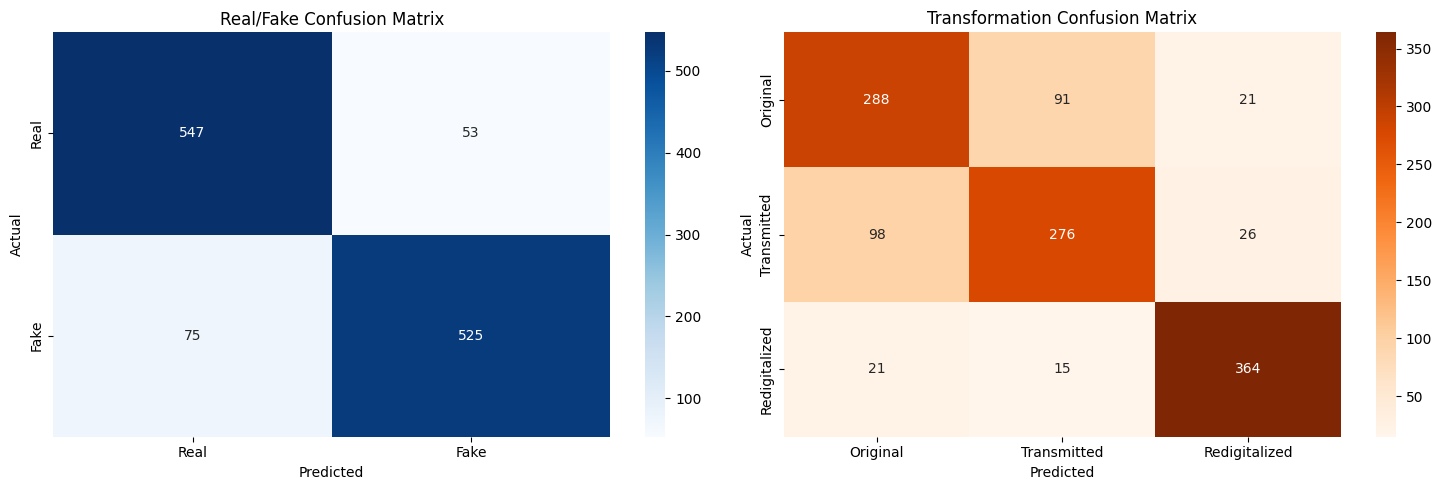

========================= REAL/FAKE REPORT =========================
              precision    recall  f1-score   support

        Real       0.88      0.91      0.90       600
        Fake       0.91      0.88      0.89       600

    accuracy                           0.89      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.89      0.89      0.89      1200


======================= TRANSFORMATION REPORT =======================
               precision    recall  f1-score   support

     Original       0.71      0.72      0.71       400
  Transmitted       0.72      0.69      0.71       400
Redigitalized       0.89      0.91      0.90       400

     accuracy                           0.77      1200
    macro avg       0.77      0.77      0.77      1200
 weighted avg       0.77      0.77      0.77      1200



In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def evaluate_multitask_performance(model, dataloader, device):
    model.eval()
    all_preds_bin, all_labels_bin = [], []
    all_preds_trans, all_labels_trans = [], []
    
    with torch.no_grad():
        for images, labels_bin, labels_trans in dataloader:
            images = images.to(device)
            out_bin, out_trans = model(images)
            
            all_preds_bin.extend(torch.max(out_bin, 1)[1].cpu().numpy())
            all_labels_bin.extend(labels_bin.numpy())
            
            all_preds_trans.extend(torch.max(out_trans, 1)[1].cpu().numpy())
            all_labels_trans.extend(labels_trans.numpy())
            
    # Plotting Matrices
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Task 1: Real/Fake Matrix
    cm_bin = confusion_matrix(all_labels_bin, all_preds_bin)
    sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    axes[0].set_title("Real/Fake Confusion Matrix")
    axes[0].set_ylabel("Actual")
    axes[0].set_xlabel("Predicted")
    
    # Task 2: Transformation Matrix
    cm_trans = confusion_matrix(all_labels_trans, all_preds_trans)
    sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=["Original", "Transmitted", "Redigitalized"],
                yticklabels=["Original", "Transmitted", "Redigitalized"])
    axes[1].set_title("Transformation Confusion Matrix")
    axes[1].set_ylabel("Actual")
    axes[1].set_xlabel("Predicted")
    
    plt.tight_layout()
    plt.show()
    
    # Print Metrics Reports
    print("="*25 + " REAL/FAKE REPORT " + "="*25)
    print(classification_report(all_labels_bin, all_preds_bin, target_names=["Real", "Fake"]))
    
    print("\n" + "="*23 + " TRANSFORMATION REPORT " + "="*23)
    print(classification_report(all_labels_trans, all_preds_trans, target_names=["Original", "Transmitted", "Redigitalized"]))

# Run metrics evaluation
evaluate_multitask_performance(model, val_loader, CONFIG["device"])

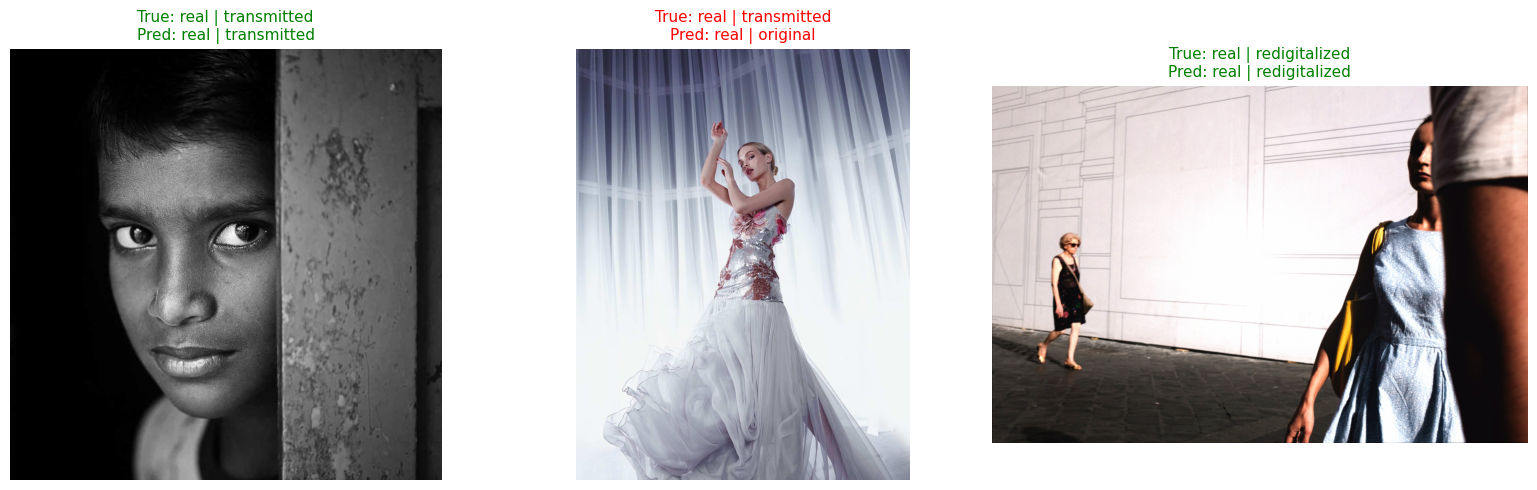

In [21]:
import numpy as np

def run_multitask_inference(model, df, num_samples=3):
    model.eval()
    inv_binary_map = {0: "real", 1: "fake"}
    inv_transform_map = {0: "original", 1: "transmitted", 2: "redigitalized"}
    
    samples = df.sample(num_samples, random_state=np.random.randint(1, 1000))
    plt.figure(figsize=(16, 5))
    
    for i, (_, row) in enumerate(samples.iterrows()):
        raw_img = Image.open(row["filepath"]).convert("RGB")
        input_tensor = val_transform(raw_img).unsqueeze(0).to(CONFIG["device"])
        
        with torch.no_grad():
            out_bin, out_trans = model(input_tensor)
            p_bin = inv_binary_map[torch.max(out_bin, 1)[1].item()]
            p_trans = inv_transform_map[torch.max(out_trans, 1)[1].item()]
            
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(raw_img)
        
        # True vs Predicted comparison
        is_correct = (p_bin == row["binary_label"]) and (p_trans == row["transform_label"])
        title_color = "green" if is_correct else "red"
        
        plt.title(
            f"True: {row['binary_label']} | {row['transform_label']}\n"
            f"Pred: {p_bin} | {p_trans}", 
            color=title_color, 
            fontsize=11
        )
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Run visual inference on 3 random validation images
run_multitask_inference(model, val_df, num_samples=3)